In [1]:
# CELL 1: Install Library (Opsional - jika ada yang kurang)
!pip install pandas numpy matplotlib seaborn scikit-learn mlflow


[notice] A new release of pip is available: 23.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# CELL 2: Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import mlflow
import mlflow.sklearn
import os

print("✅ Library berhasil diimport!")

Matplotlib is building the font cache; this may take a moment.


✅ Library berhasil diimport!


In [3]:
# CELL 3: Load Data
from sklearn.datasets import load_iris

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df['target_name'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

print("✅ Data berhasil dimuat!")
print(f"Jumlah data: {len(df)}")
print(df.head())

✅ Data berhasil dimuat!
Jumlah data: 150
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      setosa  
1       0      setosa  
2       0      setosa  
3       0      setosa  
4       0      setosa  



📊 EDA - EKSPLORASI DATA

Statistik Deskriptif:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Informasi Dataset:
<cla

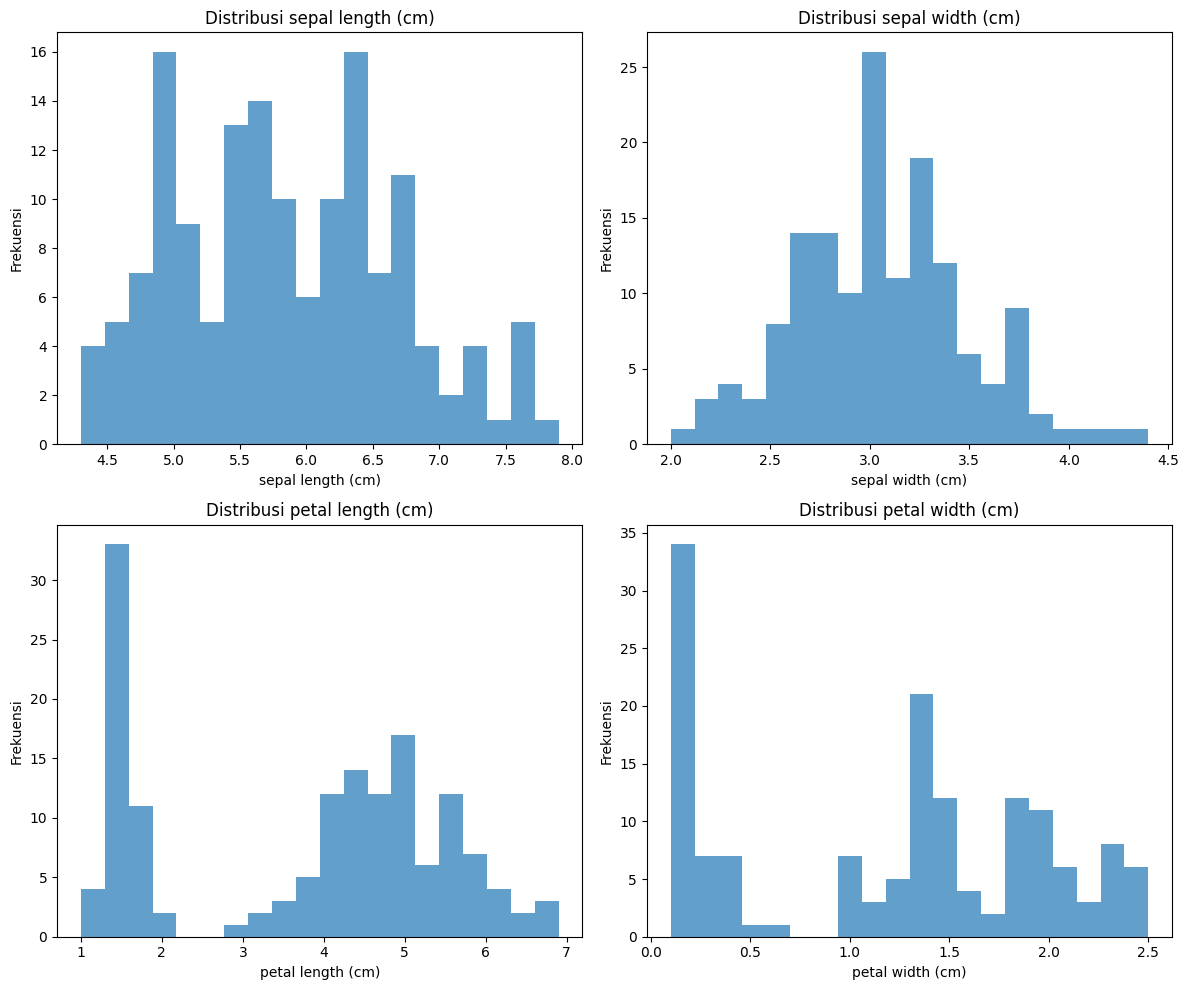

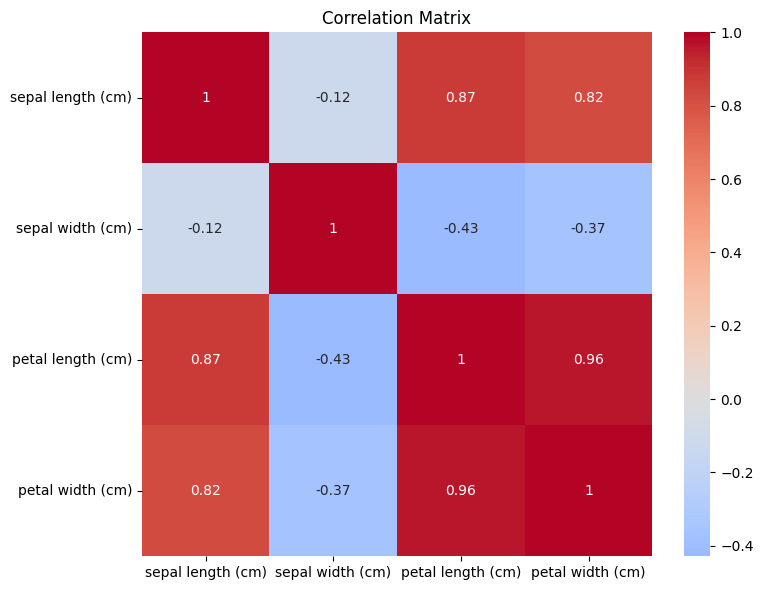

In [4]:
# CELL 4: EDA
print("\n" + "="*60)
print("📊 EDA - EKSPLORASI DATA")
print("="*60)

print("\nStatistik Deskriptif:")
print(df.describe())

print("\nInformasi Dataset:")
print(df.info())

# Distribusi setiap fitur
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(df.columns[:-2]):
    ax = axes[i//2, i%2]
    ax.hist(df[col], bins=20, alpha=0.7)
    ax.set_title(f'Distribusi {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('distribusi_data.png', dpi=300)
plt.show()

# Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df.iloc[:, :-2].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=300)
plt.show()

In [5]:
# CELL 5: Preprocessing
print("\n" + "="*60)
print("🧹 PREPROCESSING")
print("="*60)

X = df[data.feature_names]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data berhasil diproses!")
print(f"Training: {len(X_train)} data")
print(f"Testing: {len(X_test)} data")

processed_df = pd.DataFrame(X_train_scaled, columns=data.feature_names)
processed_df['target'] = y_train.values
processed_df.to_csv('dataset_preprocessing.csv', index=False)

print("✅ Dataset preprocessing tersimpan!")


🧹 PREPROCESSING
✅ Data berhasil diproses!
Training: 120 data
Testing: 30 data
✅ Dataset preprocessing tersimpan!


In [6]:
# CELL 6: Training Model
print("\n" + "="*60)
print("🤖 TRAINING MODEL")
print("="*60)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"✅ Akurasi: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


🤖 TRAINING MODEL
✅ Akurasi: 0.9000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.82      0.90      0.86        10
           2       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



In [7]:
# CELL 7: Simpan ke MLflow
print("\n" + "="*60)
print("📝 SAVE TO MLFLOW")
print("="*60)

with mlflow.start_run(run_name="Eksperimen_Iris"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", 100)
    mlflow.log_param("test_size", 0.2)
    
    mlflow.log_metric("accuracy", acc)
    
    mlflow.sklearn.log_model(model, "model")
    
    mlflow.log_artifact("distribusi_data.png")
    mlflow.log_artifact("correlation_matrix.png")
    
    print("✅ Eksperimen berhasil disimpan ke MLflow!")


📝 SAVE TO MLFLOW


2026/07/30 18:18:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/30 18:18:20 INFO mlflow.store.db.utils: Updating database tables
2026/07/30 18:18:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Eksperimen berhasil disimpan ke MLflow!
